## Assignment 2

## Dimensionality Reduction 

## CSCI E-108

### Steve Elston


## Introduction  

Dimensionality reduction algorithms are widely used in data mining. Human perception of relationships in data is limited beyond a few dimensions. Further, many data mining algorithms produce poor results where when there is significant dependency between the features or variables. In both cases, we can apply dimensionality reduction methods.   

In the exercises in this notebook you will gain some experience working with some commonly used dimensionality reduction methods. Specifically, there are two distinct classes of algorithms you will explore:    
1. **Dimensionality reduction transformation methods** create operators to map a sample (feature) space to an orthogonal space. Typically the original data can be well-represented in lower dimensions in the orthogonal space. Examples of these methods include principle component analysis (PCA) and singular value decomposition (SVD).    
2. **Manifold learning methods** where data in a high dimensional space is mapped onto a lower-dimensional manifold. When the projection is to a low dimension, manifold learning is used to aid visualization of high-dimensional data. Alternatively, manifold learning can be used as a nonlinear map for dimensionality reduction for further analysis.   

> **Instructions:** For this assignment you will complete the exercises shown. All exercises involve creating and executing some Python code. Additionally, most exercises have questions for you to answer. You can answer questions by creating a Markdown cell and writing your answer. If you are not familiar with Markdown, you can find documentation and a brief tutorial [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html).
> 
> When you have completed the exercises, upload your completed notebook to Canvas.

To begin, execute the code in the cell below to import the packages you will need. 

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import SpectralEmbedding, MDS, TSNE
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics.pairwise import (
    pairwise_distances,
    cosine_similarity,
    cosine_distances,
    euclidean_distances,
)

# from sklearn import random_projection
import umap
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import math
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import umap

## A Synthetic Example

To make the ideas of dimensionality reduction clear, we start with an extremely simple example. In this example, dimensionality reduction is applied to bivariate Normally distributed data. The code in the cell below does the following:  
1. Generate 500 samples from a bivariate, zero-centered Normal distribution with covariance having a high degree of dependency between the variables:  
$$
cov = 
 \begin{bmatrix}
   1.0 & 0.9\\
   0.9 & 1.0
   \end{bmatrix}
$$
2. Print the empirical covariance matrix of the sample.  
3. Plot the simulated data values.

Execute this code.

The emperical covariance
[[1.02657695 0.91440274]
 [0.91440274 0.99100602]]


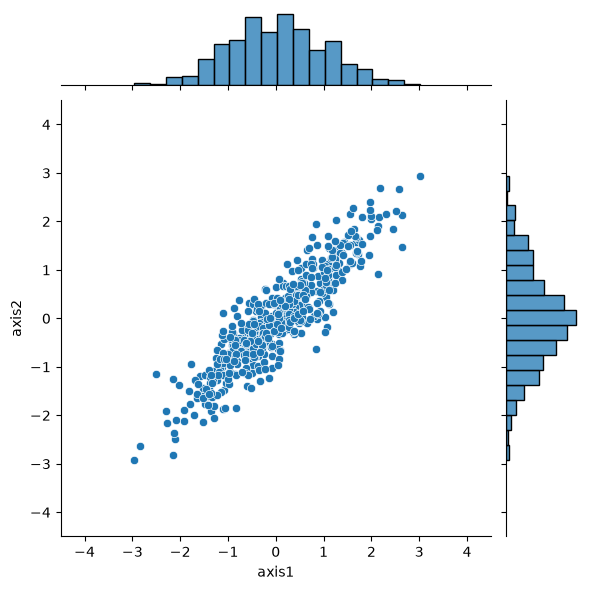

In [2]:
def plot_normal(X):
    X = pd.DataFrame(X, columns=["axis1", "axis2"])
    _ = sns.jointplot(x="axis1", y="axis2", data=X, xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))


cov = [[1, 0.9], [0.9, 1]]
np.random.seed(367)
Normal_random = np.random.multivariate_normal([0.0, 0.0], cov, size=500)
print("The emperical covariance")
print(np.cov(Normal_random[:, 0], Normal_random[:, 1]))
plot_normal(Normal_random)

Notice the following aspects of these results:  
1. The empirical covariance matrix is very close in values to the covariance matrix used for the simulation.   
2. The scatter plot shows considerable dependency between the two variables. 
3. The marginal distributions of the two variables appear to be close to Normally distributed. 

Next, the code in the cell below does the following.  
1. A PCA object is instantiated and the data fit.   
2. The PCA model is used to transform or project the original data matrix into the new coordinate system.    
3. The empirical covariance is computed and printed. 
4. **Variance ratio** of the two dimensions of the new space is computed and printed. Here, variance ratio is the variance on each dimension of the space divided by the total variance of the data. 
5. A plot of the projected data values in the new coordinate space is plotted. 

Execute this code. 

Covariance of the transformed data
[[ 1.92336718e+00 -4.39639418e-16]
 [-4.39639418e-16  9.42157896e-02]]

The variance explained ratio = [0.95330264 0.04669736]


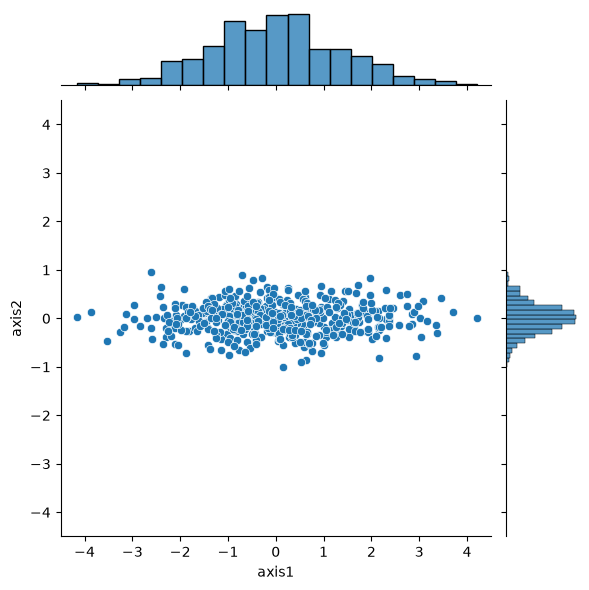

In [3]:
Normal_pca = PCA().fit(Normal_random)
simple_pca = Normal_pca.transform(Normal_random)
print("Covariance of the transformed data")
print(np.cov(simple_pca[:, 0], simple_pca[:, 1]))
print(f"\nThe variance explained ratio = {Normal_pca.explained_variance_ratio_}")
plot_normal(simple_pca)

The PCA transformation of these data appears to have worked as expected. Notice the following:  
1. The diagonal terms of the covariance matrix are significantly different in value, indicating that the first component (axis) projects the majority of the variance of the data.  
2. The off-diagonal terms of the covariance matrix are effectively 0, indicating there is no dependency between the variables in the new coordinate system. 
3. The observation that most of the variability of the projected data are explained by the first component is confirmed by both the variance ratio values and the scatter plot. 
4. The marginal distributions of the two variables are very close to Normal, but with significantly difference scale or variance. 

## First Running Example  

We will now start working with some simple real-world data. The famous Iris dataset was collected by a botanist named Edgar Anderson around 1935. Subsequently, the dataset became famous in data analysis circles when Ronald A Fisher used it as an example for his seminal 1936 paper on discriminate analysis, one of the first true multivariate statistical methods proposed. By modern standards this data set is small (only 150 samples) and simple (only 4 features), but the simplicity will help in understand the methods at hand.   

The code in the cell below loads the data set and transforms it into a de-meaned Pandas data frame with human readable column and species names. Execute this code. 

In [4]:
iris_data = load_iris()

## Normalize the data values
temp = (iris_data["data"] - iris_data["data"].mean(axis=0)) / iris_data["data"].std(axis=0)

## Prepare the data frame
target_species = {0: "Setosa", 1: "Versicolour", 2: "Virginica"}
species = [target_species[x] for x in iris_data["target"]]
iris = pd.DataFrame(temp, columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
iris["species"] = species
iris_data = temp
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.900681,1.019004,-1.340227,-1.315444,Setosa
1,-1.143017,-0.131979,-1.340227,-1.315444,Setosa
2,-1.385353,0.328414,-1.397064,-1.315444,Setosa
3,-1.506521,0.098217,-1.283389,-1.315444,Setosa
4,-1.021849,1.249201,-1.340227,-1.315444,Setosa
...,...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832,Virginica
146,0.553333,-1.282963,0.705921,0.922303,Virginica
147,0.795669,-0.131979,0.819596,1.053935,Virginica
148,0.432165,0.788808,0.933271,1.448832,Virginica


Since there are only 4 features in this dataset a pairs plot will help with understanding the relationships in these data. Execute the code below to display the plot. 

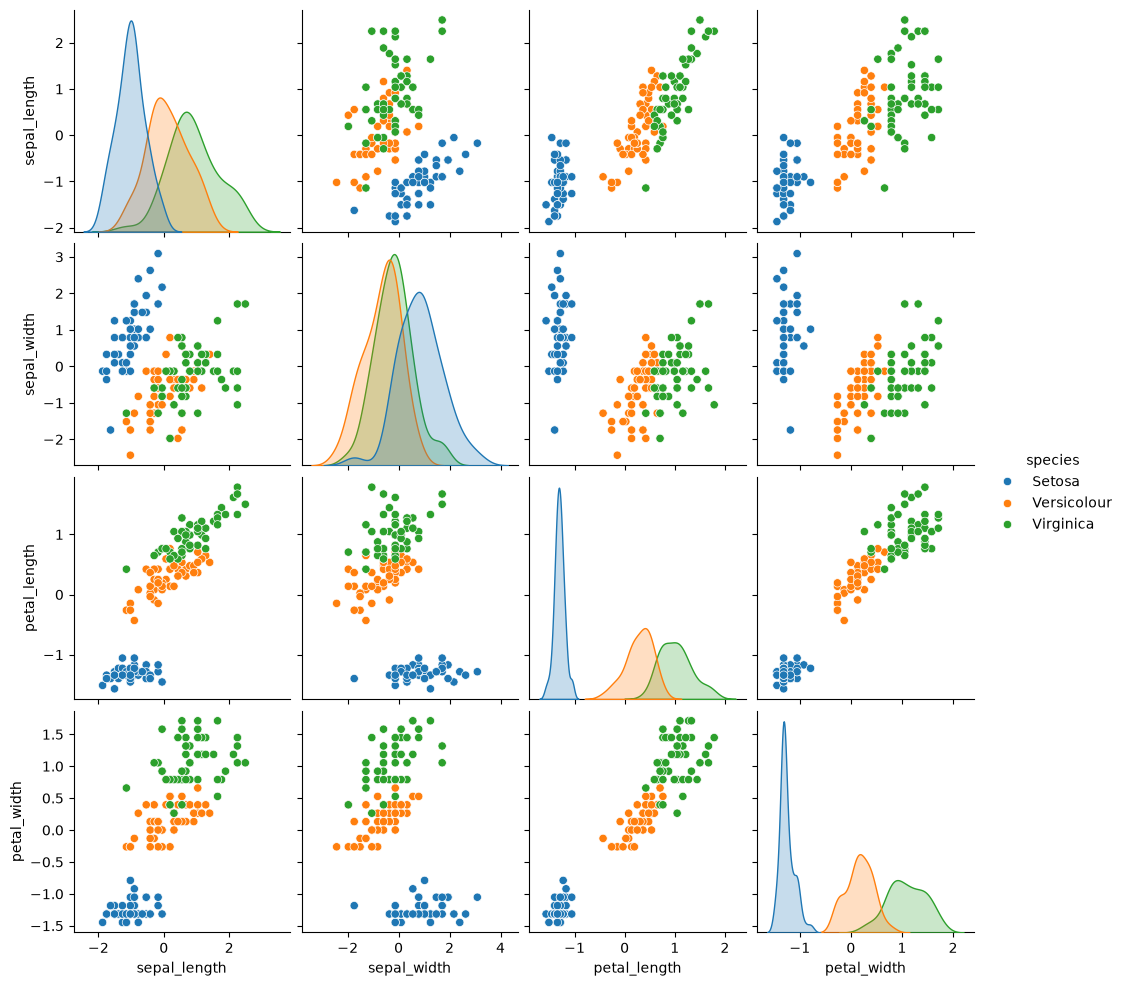

In [5]:
_ = sns.pairplot(iris, hue="species")

Examine this plot array. You can see that values samples for the Setosa species are well separated. However there is some overlap between samples from Versicolour and Virginica. Further, and more importantly, it appears that these is considerable redundancy in these plots. This leads one to suspect that there is a high dependency between these cases.  

We can further investigate the dependency between the variables by computing the covariance matrix. Execute the code in the cell below to compute the covariance matrix of the iris data. 

Iris covariance matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.006711    -0.118359      0.877604     0.823431
sepal_width      -0.118359     1.006711     -0.431316    -0.368583
petal_length      0.877604    -0.431316      1.006711     0.969328
petal_width       0.823431    -0.368583      0.969328     1.006711


<Axes: >

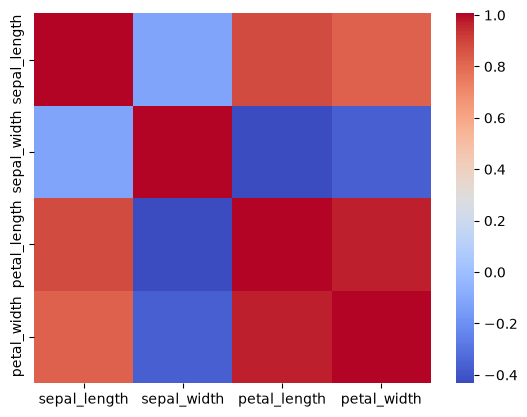

In [6]:
iris_convariance = pd.DataFrame(
    np.cov(np.transpose(iris_data)), index=list(iris.columns)[:-1], columns=list(iris.columns)[:-1]
)
print("Iris covariance matrix")
print(iris_convariance)
sns.heatmap(iris_convariance, cmap="coolwarm")

Several of the off-diagonal terms of the covariance matrix are far from zero. We can conclude that there is significant dependency between the variables.   

## Compute PCA of the iris data   

The first algorithm you will apply to the iris data is linear PCA.  

> **Exercise 2-1:** Compute the PCA of the iris data and plot the explained variance of the components by the following steps:  
> 1. Instantiate a Scikit-learn PCA model object with [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).  
> 2. Fit the model to `iris_data` numpy array using the `fit` method on the model object.  
> 3. Display a scatterplot of with the `explained_variance_ratio_` attribute of the fitted model vs. the component number.  

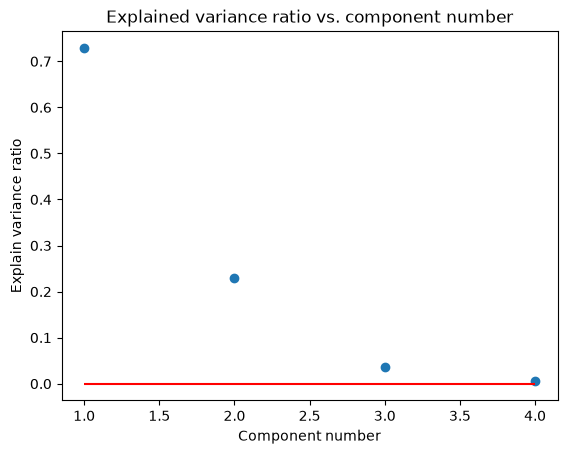

In [7]:
def plot_variance_ratio(pca_model, n_components):
    _ = plt.scatter(range(1, n_components + 1), pca_model.explained_variance_ratio_)
    _ = plt.hlines(0, 1, n_components, color="red")
    _ = plt.xlabel("Component number")
    _ = plt.ylabel("Explain variance ratio")
    _ = plt.title("Explained variance ratio vs. component number")


## Put your code below
iris_pca = PCA().fit(iris_data)

## Display the results
n_components = 4
plot_variance_ratio(iris_pca, n_components)

> Examine the plot and answer these questions: 
> 1. Does it appear that much of the variance in the data is explained by the first component and why?  
> 2. Is there any substantial difference in the variance explained between the second and third and fourth components?   

> **Answers:**    
> 1. Yes, it's explanation of variance ratio is more than 3x the second highest one, and it is more than half of the total impact on the final outcome (70%)   
> 2. Yes, we see the subsequent features after the first one asymptotically approach 0 feature significance. The second feature is still considerably more significant than the third and so on. The second feature is a little over .2 for its ratio, the third around .05, and the fourth is very close to 0. 

> Recall that the variance of the components from the PCA goes as the square of the singular values. You can gain another view of the relationship between the principle components by executing the code below to plot the singular values. 

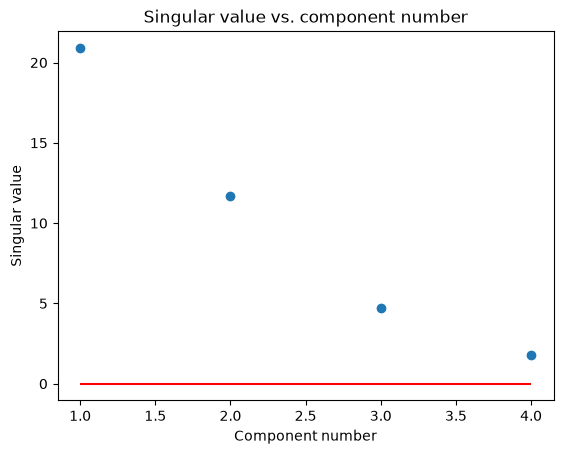

In [8]:
_ = plt.scatter(range(1, len(iris_pca.singular_values_) + 1), iris_pca.singular_values_)
_ = plt.hlines(0, 1, len(iris_pca.singular_values_), color="red")
_ = plt.xlabel("Component number")
_ = plt.ylabel("Singular value")
_ = plt.title("Singular value vs. component number")

> 3. Are these singular values consistent with the variance explained for the components?     
> **End of exercise.**

> **Answer 3:** Yes, though it is not exactly the same, the curve has pretty much the same shape. Each component still has considerably smaller significance than the last, though the jumps are slightly smaller here proportionally. 

Next, you will investigate the principle components used to project the data into the new space. Execute the code in the cell below to print the components.  

In [9]:
components = iris_pca.components_
components

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199],
       [ 0.71956635, -0.24438178, -0.14212637, -0.63427274],
       [-0.26128628,  0.12350962,  0.80144925, -0.52359713]])

The eigenvectors are in the columns of this array. These eigenvectors are the projections of the original sample space onto the orthogonal space.  

> **Exercise 02-2:** The principle components must be unitary, that is have unit norm, and be orthogonal. Complete and execute the code in the cell below by doing the following to verify these properties.  
> 1. Compute and print the Euclidean norm of these of the components using [numpy.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html).    
> 2. Using [itertools.combinations](https://docs.python.org/3/library/itertools.html) compute the dot (inner) product of each of pairwise combination of the components using [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html).


In [10]:
print("The euclidean norm of the components:")
## Put your code below
print(np.linalg.norm(components, axis=1))


print("\nThe dot products between the components:")
## Put your code below
for i, j in itertools.combinations(range(n_components), 2):
    print(np.dot(components[i], components[j]))

The euclidean norm of the components:
[1. 1. 1. 1.]

The dot products between the components:
-7.216449660063518e-16
0.0
1.6653345369377348e-16
1.6653345369377348e-16
-1.942890293094024e-16
-5.551115123125783e-17


> Examine these results. Are the eigenvectors orthogonal and unitary and how can you tell?   
> **End of exercise.**

> **Answers:** You can tell they are orthogonal since all the dot products of the components are zero or very very close to zero. You can tell it is unitary because as well as being orthogonal, we can see it has unit norm since the euclidean norm of all the components are 1. 

> **Exercise 2-3:** From the initial exploration of the variance explained and singular values it is the case that a few components can explain most of the variance. To project the 4-dimensional data space to a lower dimensional space do the following:   
> 1. Examine the break in the curve for both the explained variance and singular values. This break-point determines the number of components you should use for the projection. 
> 2. Instantiate the projected data array using a PCA model object, with the `n_components` arguments and apply the `fit_transform` method on the `iris_data`.   
> 3. Plot the transformation of the data with the `plot_pca` function provided. Make sure you save the returned data frame as `pca_projected`.
> 4. Execute your code.  

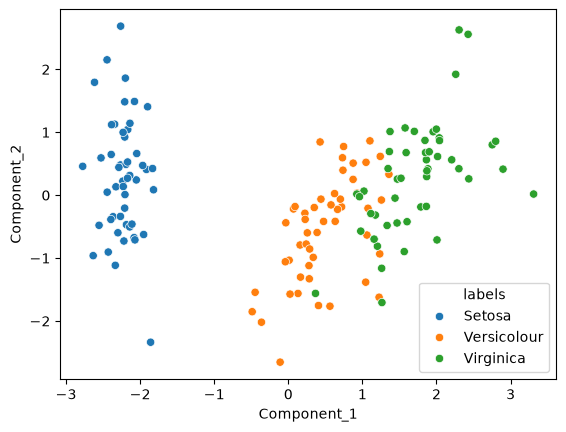

In [11]:
def plot_pca(X, labels, ax=None):
    pca_projected = pd.DataFrame(X, columns=["Component_1", "Component_2"])
    pca_projected["labels"] = labels
    if ax == None:
        sns.scatterplot(data=pca_projected, x="Component_1", y="Component_2", hue="labels")
    else:
        sns.scatterplot(data=pca_projected, x="Component_1", y="Component_2", hue="labels", ax=ax)
    return pca_projected


## Put your code below
iris_pca = PCA(n_components=2).fit_transform(iris_data)


## Plot and save the results
pca_projected = plot_pca(iris_pca, species)

> Examine the plot you have created. Answer the following questions:  
> 1. How well can these groups be linearly separated, thereby separating the specie, and why?  
> 2. Notice the different scales of the two projected variables. Is the range of values of the components consistent with the variance of the components?    


> **Answers:**       
> 1. The Setosa can be very easily linearly separated from the other two groups as it is entirely in a space of its own to the left. Versicolour and Virginica cannot be perfectly linearly separated, but you could do it in such a way that it only would miss a few points from either cluster.        
> 2.  Yes, there is more variance on the X axis, the clusters are both more spread out along the X axis, and the differences that divide the groups are mostly explainable by the X axis ( x < -2 is Setosa  x < 1 is Versicolour and x > 1 is Virginica). That axis is also the one with a larger range.    

> We can check the independence of the components by computing the covariance. In the cell below create and execute code to . to display the covariance of the projected components. 

In [12]:
## Put your code below.
print(np.cov(pca_projected.Component_1, pca_projected.Component_2))

[[ 2.93808505e+00 -8.58373775e-16]
 [-8.58373775e-16  9.20164904e-01]]


> 3. Notice the small values of the off-diagonal components. Do these values indicate the components are orthogonal.     
> **End of Exercise.**

> **Answer 3:**  Yes, but more directly means they are uncorrelated when the covariance of the off-diagonal is very close to zero. This is the behavior you would expect to see when the components are orthogonal. 

## Second Example Dataset

The bowl disease gene dataset has high dimensionality, with over 10,000 features. There are data from 97 patients (rows) with 10,497 gene responses (features in columns). Some of these patients have ulcerative colitis, a condition believed not to be inheritable, and others have Crohn's disease, which is believed to be genetically inherited.

The question is, can this high dimensional space be projected to a lower dimensional space?  

Execute the code in the cell below to load the data set and prepare it for analysis. 

In [13]:
gene_data = pd.read_csv("../data/ColonDiseaseGeneData-Cleaned.csv")
labels = gene_data.loc[:, "Disease State"]
gene_data = gene_data.drop("Disease State", axis=1)

## Normalize the columns
gene_data = (gene_data - gene_data.mean(axis=0)) / gene_data.std(axis=0)

## Display the results
print("Shape of the data array = " + str(gene_data.shape))
print(gene_data.head())

Shape of the data array = (97, 10497)
    FAM138F  LOC100133331  LOC100132062  LOC388312  BC016143  BC071797  \
0  0.037249     -0.291076     -0.468366  -0.565637 -1.205652  0.986297   
1  2.703451     -0.857027     -0.466911  -0.248338 -0.872731 -0.190712   
2 -1.514233      0.406056      0.401003   0.519990 -0.492251  0.996789   
3  1.247350     -1.311608     -1.493856  -1.296212  0.197563 -0.534373   
4  0.223893     -0.621705     -0.707016  -0.745680 -0.853011 -0.022725   

   AX746564  LINC00623    FAM45B      DUX4  ...     TTLL3     TTLL4     TTLL5  \
0 -0.503054   0.635754  0.591468  0.050201  ...  0.121856 -0.505228  0.590142   
1 -0.424813   0.144463 -0.198031  1.106732  ... -0.011350 -0.965304 -0.104514   
2  0.013537   0.606253  1.070210 -0.337467  ... -0.268654  0.943829  1.969924   
3  0.400227  -2.105780  2.243384  1.886012  ...  0.833996  0.451874 -0.653959   
4 -1.805564  -0.575825 -1.120419 -0.927462  ...  0.041022  0.705459 -0.277757   

      TTLL6     TTLL7     TTLL

For the 97 subjects there are gene expression values for over 10,000 genes. The limited number of samples and extreme high dimensionality makes this a challenging problem.     

To get a feel for these data, execute the code in the cell below to create and display a Euclidean only UMAP embedding of the gene data.  

Text(0.5, 1.0, 'UMAP projection of standardized gene dataset')

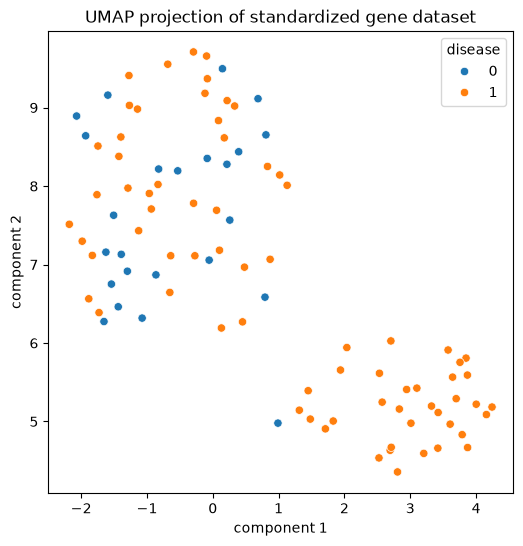

In [14]:
np.random.seed(4365)
gene_embedding = umap.UMAP().fit_transform(gene_data)

gene_embedding_df = pd.DataFrame(gene_embedding, columns=["component1", "component2"])
gene_embedding_df["disease"] = [0 if label == "Ulcerative Colitis (UC)" else 1 for label in labels]

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=gene_embedding_df, x="component1", y="component2", hue="disease", ax=ax)
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.set_title("UMAP projection of standardized gene dataset")

On the plot, the disease state is coded as 1 for Crohn's Disease and 0 for Ulcerative Colitis. By examining the plot is apparent that there is one grouping of patients with Crohn's Disease that is isolated from the others. There is another grouping where patients with both conditions appear mixed. These observations confirm that separating this second group by disease is likely to be quite challenging.  

## PCA with Gene Data    

> **Exercise 2-4:** You will now explore the ability of PCA to reduce the dimensionality of the genetics data. To test this idea do the following:   
> 1. Instantiate a PCA object and apply the `fit` method with the `gene_data` as the argument.  
> 2. Print the cumulative sum of the variance explained by applying the [numpy.cumsum](https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html) function to the `explained_variance_ratio_` attribute of the model object. 
> 2. Plot the first 60 components of the `explained_variance_ratio_` attribute of the model object vs. the component number. 
> 3. Execute your code. 

The cumulative variance explained by the first 50 componenets = 0.882179030098858
The full cumulative sums of the variance compoents:
[0.19744729 0.30715637 0.40512924 0.47612652 0.51618141 0.54888216
 0.57457227 0.59730935 0.61784554 0.63514969 0.65102267 0.6645669
 0.67668888 0.68870231 0.6995324  0.7093417  0.71797902 0.72592963
 0.73314569 0.74023849 0.74689214 0.75339877 0.75956477 0.76541687
 0.77109478 0.7766969  0.78216118 0.78736369 0.79244852 0.79737814
 0.80223947 0.80697126 0.81155868 0.81608333 0.820582   0.82491358
 0.82917238 0.83339176 0.83751065 0.84153554 0.84553019 0.84949856
 0.85338464 0.85717575 0.86093119 0.86462334 0.86824973 0.87179689
 0.87531155 0.87878244 0.88217903 0.88553752 0.88884348 0.89213425
 0.89537022 0.89855472 0.9017166  0.90483473 0.90792369 0.91098216
 0.91401584 0.91699746 0.91995369 0.92289479 0.92579413 0.92866494
 0.93151476 0.93435316 0.93715958 0.93991837 0.94266916 0.94538831
 0.94807197 0.95068357 0.95325638 0.95581581 0.95836068 0.96089

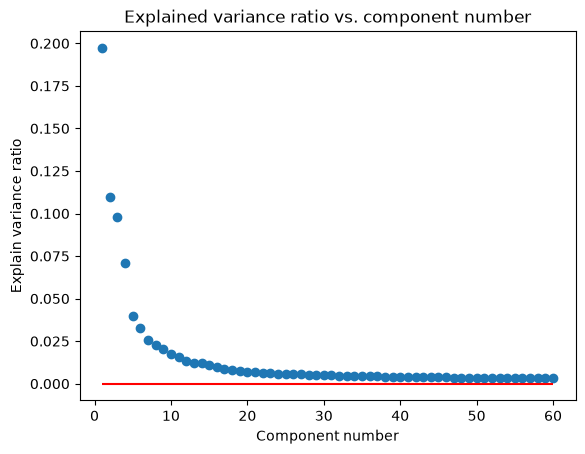

In [15]:
## Put your code below
gene_pca = PCA().fit(gene_data)
cumsums = np.cumsum(gene_pca.explained_variance_ratio_)

print("The cumulative variance explained by the first 50 componenets = " + str(cumsums[50]))
print("The full cumulative sums of the variance compoents:")
print(cumsums)

## Display the explained variance ratio vs. component
n_components = 60
_ = plt.scatter(range(1, n_components + 1), gene_pca.explained_variance_ratio_[:n_components])
_ = plt.hlines(0, 1, n_components, color="red")
_ = plt.xlabel("Component number")
_ = plt.ylabel("Explain variance ratio")
_ = plt.title("Explained variance ratio vs. component number")

> Study your plot. Notice that the explained variance ratio decreases rapidly with the component number. Answer the following questions:  
> 1. From the cumulative sums of the variance explained, approximately how much of the total variance can be explained by the first 39 components?  
> 2. Does the decay of the variance explained curve indicate that significant dimensionality reduction is possible for these data?   

> **Answers:**    
> 1. Somewhere around 99%  
> 2. Yes. After the first 10-20 results the explained variance ratio gets very very small for further features. Also, the first few have ratios as much as 5 - 10x the features in the 10-20 range.         

> Now you will display and examine a pairwise scatter plot of the first components of the PCA decomposition of the genetics data. Execute the code below with the number of components representing a cumulative 60% of the variance.    

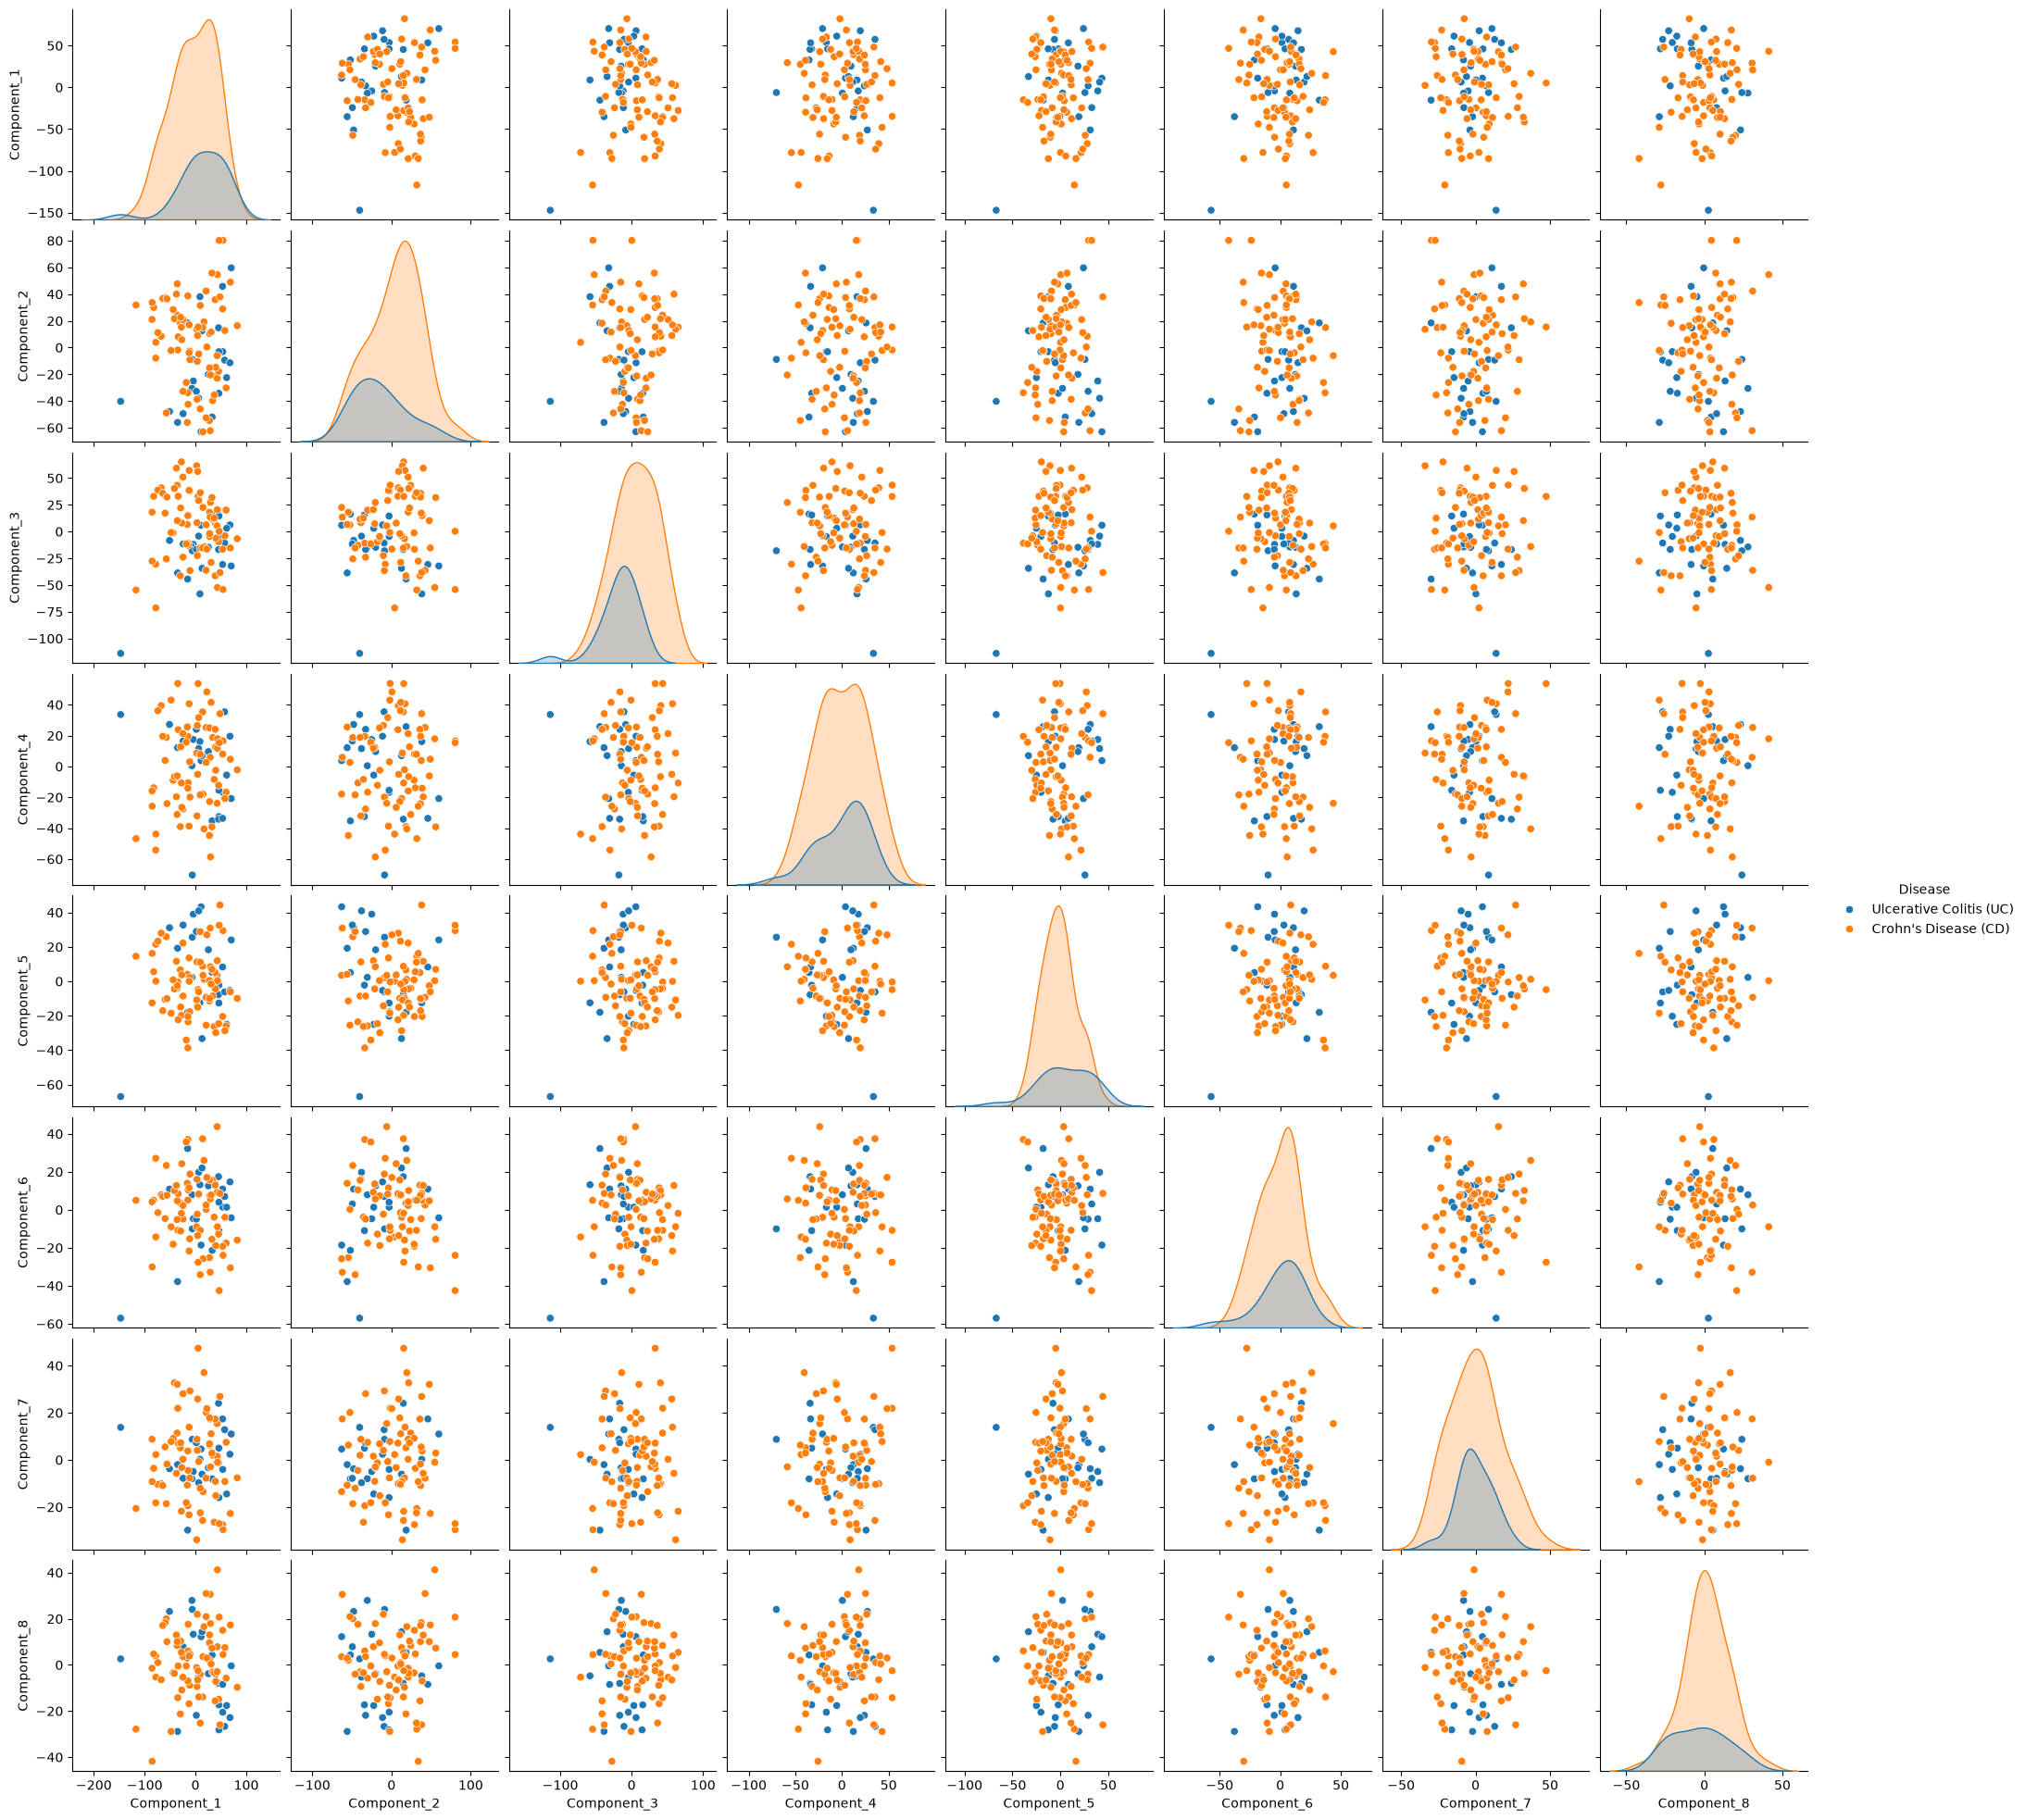

In [16]:
## Display the components
n_components = 8
gene_components = [
    "Component_1",
    "Component_2",
    "Component_3",
    "Component_4",
    "Component_5",
    "Component_6",
    "Component_7",
    "Component_8",
]
gene_pca_8 = PCA(n_components=n_components).fit(gene_data)
gene_pca_projected = pd.DataFrame(gene_pca_8.transform(gene_data), columns=gene_components)
gene_pca_projected["Disease"] = labels
_ = sns.pairplot(gene_pca_projected, hue="Disease")

> Examine the plot. Notice that most of the component values of the two disease types have significant overlap. However, in some cases there are differences in the values on the scatter plots and the marginal density plots. What do these relationship indicate about the ability of these components to separation of the two disease conditions?      
> **End of exercise.**  

> **Answer 3:**   While the graphs do not look entirely the same, there is one commonality between all of them. The region containing the blue points is always entirely contained within/overlapping the region the orange points are in. You can see it the most clearly on the density plots on the diagonal, where the blue region is directly inside the orange region on every single plot (other than a tiny bit of the lower tail in some and the upper tail in one). We can see a single blue point that is not within either cluster, and hangs off to the side in most of the plots. This is likely an outlier, not a useful pattern that it is outside the orange region. Also, due to the class imbalance, and the inability to separate the groups based on these features, the blue points just seem like a subset within the orange points, not their own group. It seems none of these components do a particularly good job separating these two diseases.   

## Manifold Learning  

Manifold learning seeks to map high-dimensional data onto a low-dimensional linear or nonlinear manifold. **Nonlinear manifold learning supports non-Euclidean spaces** a major advantage compared to PCA. As where any dimensionality reduction algorithm, there are two reasons to apply manifold learning.      
1. To create a low-dimensional projection, $\le 4$, to aid in visualization of complex data relationships.
2. To reduce dimensionality to improve performance of machine learning models, such as unsupervised clustering models.  

To start our exploration of manifold learning we will map to a two dimensional manifold which can be displayed as a plot showing relationships in complex, high dimensional data. 

The Scikit-Learn package contains a large number of linear and nonlinear [manifold learning algorithms](https://scikit-learn.org/stable/modules/manifold.html). Here we will only investigate two possibilities, spectral manifold learning and the [UMAP algorithm](https://umap-learn.readthedocs.io/en/latest/index.html).   

> **Manifold leaning is not clustering!** It is a common misconception that manifold learning models are clustering models. While it is the case that manifold projections of complex data can show grouping of observations, these groupings must not be confused with clusters. In contrast, clustering algorithms compute specific cluster assignments to the observations, which manifold learning does not do.  

### Spectral Manifold Learning 

> **Exercise 2-5:** You will now apply the spectral manifold learning to the iris dataset by these steps:   
> 1. Instantiate a [sklearn.manifold.SpectralEmbedding](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.SpectralEmbedding.html#sklearn.manifold.SpectralEmbedding) object with argument `affinity='rbf'`, or [radial basis function](https://en.wikipedia.org/wiki/Radial_basis_function). The radial basis function makes the transformation localized and nonlinear. 
> 2. Use the `fit_transform` method with the iris data as the argument. 
> 3. Display the result using the `plot_pca` function.  

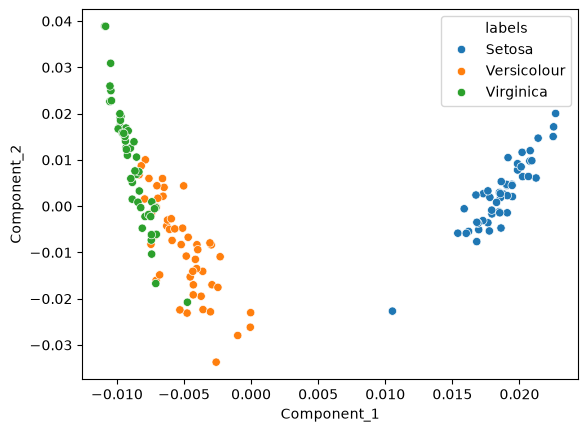

In [17]:
## Put your code below
iris_spectral = SpectralEmbedding(affinity="rbf").fit_transform(iris_data)

pca_projected = plot_pca(iris_spectral, species)

> Examine this plot. Which aspects (groupings) of the data are well separated?  
> **End of exercise.**

> **Answer:**     The Setosas are very clearly separated, as their cluster is not even adjacent to any of the others, occupying its own half of the graph, with no other colored points anywhere nearby. The Versicolour and Virginica are also mostly distinct from each other in this representation. Their clusters are adjacent, and an attempt to draw a straight line between them would miss a few points in either direction, but would correctly separate the majority of the points. 

### UMAP      

You have been previously used the UMAP algorithm for visualization of groups in data. You will now work with some properties of this Algorithm. As a starting point, execute the code in the cell below to display the embedding computed with the UMAP algorithm with default arguments, which include Euclidean space and computation on only two components. This plot will give you a baseline to compare the effects of changing hyperparameters.    

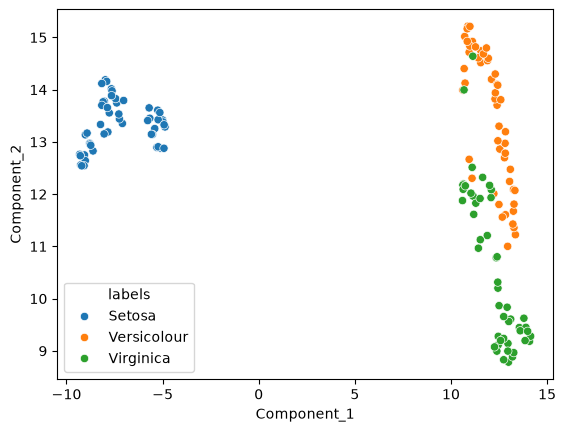

In [18]:
np.random.seed(8273)
iris_UMAP = umap.UMAP().fit_transform(iris_data)
umap_projected = plot_pca(iris_UMAP, species)

> **Warning!** The best choices of hyperparameters are dependent on both the properties of the dataset and the analytical objectives. There is no reason to believe that a particular choice of hyperparameters will transfer to another dataset or another problem with the same dataset. Do not make this mistake! 

There are a number of key hyperparameters that affect the results produced by the UMAP algorithm. Here, we will focus on two, `n_neighbors` and `min_dist`. You can see additional examples of the effects of changing these hyperparamters in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/parameters.html). 

The default values of the two parameters of interest here are, n_neighbors=15 and min_dist=0.1. The code in the cell below tests all possible pairs of hyperparameters that are 0.2 and 5.0 times the default values. The embedding for each hyperparameter pairs is then displayed. Execute this code and examine the result.      

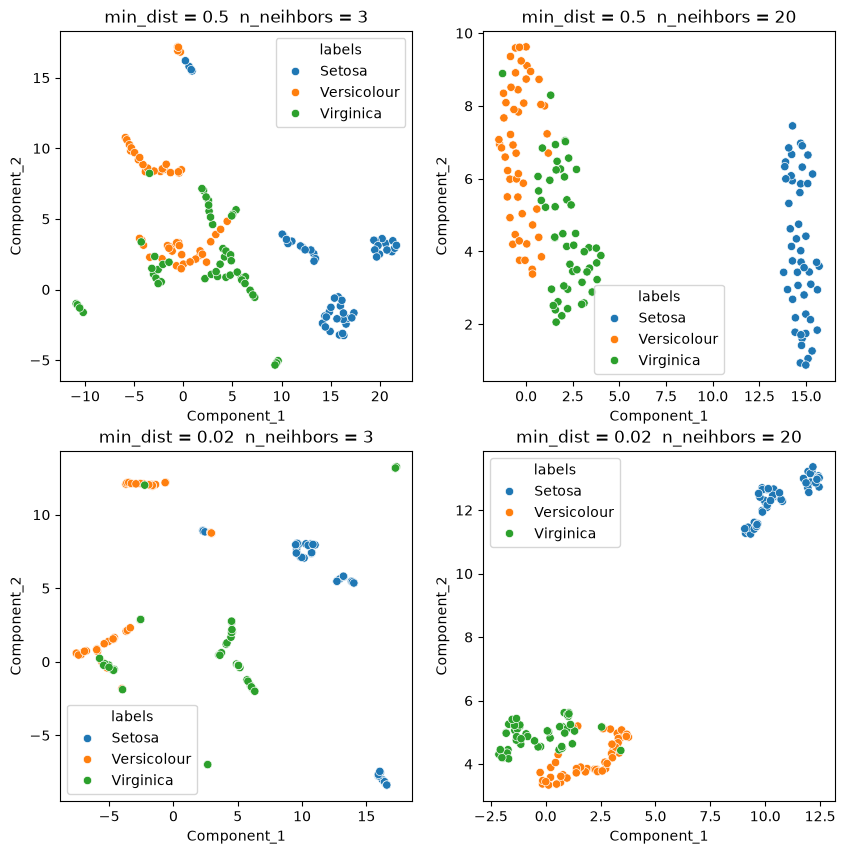

In [19]:
min_dist_list = [0.5, 0.5, 0.02, 0.02]
n_neighbor_list = [3, 20, 3, 20]
_, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
np.random.seed(6655)
for i, (min_dist, n_neighbors) in enumerate(zip(min_dist_list, n_neighbor_list)):
    iris_UMAP = umap.UMAP(min_dist=min_dist, n_neighbors=n_neighbors).fit_transform(iris_data)
    umap_projected = plot_pca(iris_UMAP, species, ax=ax[i])
    ax[i].set_title("min_dist = " + str(min_dist) + "  n_neihbors = " + str(n_neighbors))

> **Exercise 2-6:** Examine these plots. Notice how the clusters change in the embedding. Now answer the following questions:     
> 1. How does changing the value of `n_neighbors` change the characteristics of the clusters shown in the embeddings plotted. Why is this behavior expected?          
> 2. How and for which plots does the display of the clusters on the embedding with different values of `min_dist` appear to be the most fragment the grouping of the members of the clusters?  

> **Answers:**       
> 1. As you lower n_neighbors we see more individual clusters, as we raise it we see fewer. This makes sense if n_neighbors is smaller, less points will be considered when determining what goes into an individual cluster, and we will see more of them. In this example, at very low numbers for n_neighbors, we end up with more clusters than correspond to the number of groups we know exist in the data, and it is hard to see the patterns we see in the other examples or at the high values for n_neighbors.      
> 2. Though both plots with the low value for n_neighbors have more fragmented groups than the others, within the n_neighbors = 3 and the n_neighbors = 20 groups, always the plot with min_distance = 0.02 is the more fragmented of the two. When the min_distance is smaller, we can see it creates sub-clusters and doesn't find the shape of the entire cluster as nicely.     

### UMAP projection of gene data

The UMAP algorithm allows us to **map from a non-Euclidean space to a Euclidean space**. Here we test **mapping from cosine distance to Euclidean distance**. You can now examine the result of changing the hyperparameter values for the embedding of the gene data. As a first step, we execute the code in the cell below to display a baseline projection using cosine distance and the default hyperparameters for `n_neighbors` $= 15$ and `min_dist` $= 0.1$.      

> **Note on cosine distance:** Euclidean and cosine metrics are the two most commonly used distance measures. Cosine distance is commonly used for **vector similarity search**, which will be the focus of future lessons in this course. 

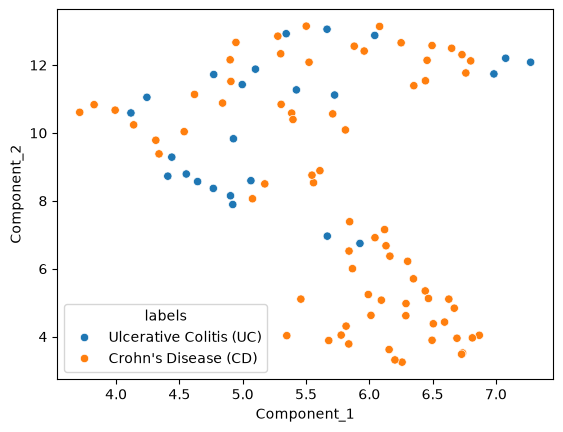

In [20]:
np.random.seed(8833)
gene_UMAP = umap.UMAP(metric="cosine").fit_transform(gene_data)
umap_projected = plot_pca(gene_UMAP, labels)

Next, execute the code in the cell below to display the embeddings for the pairs of values for `n_neighbors` and `min_dist`, including the default hyperparameters. Since this is a more challenging problem, we are extending the hyperparameter search range. The range of `n_neighbors` is limited by the small number of subjects.  

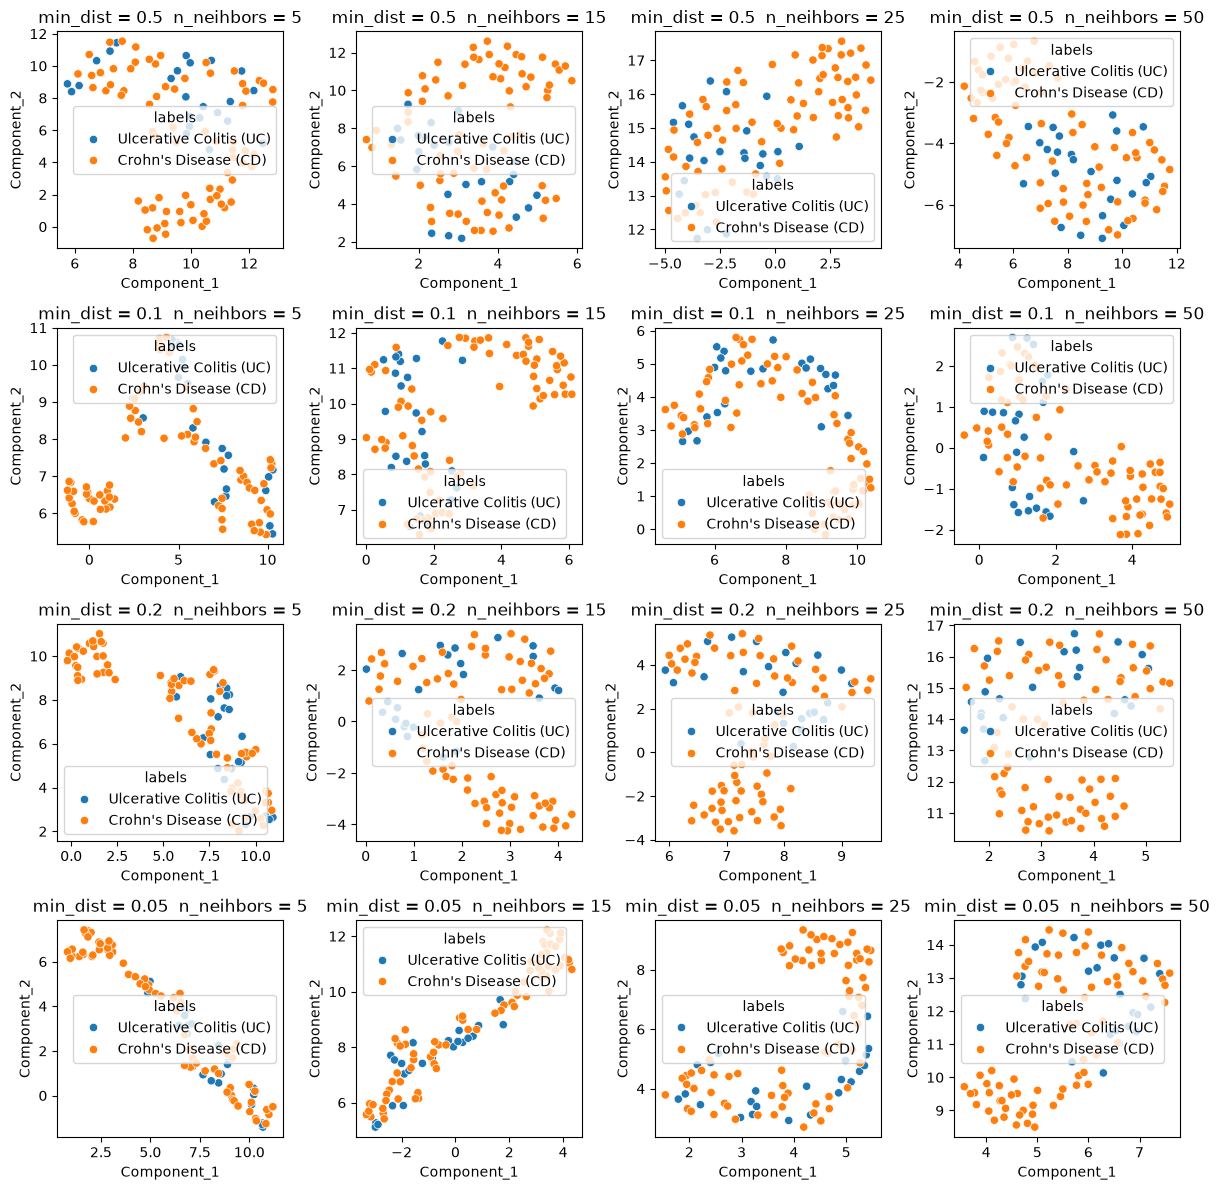

In [ ]:
n_neighbor_list = [5, 15, 25, 50, 5, 15, 25, 50, 5, 15, 25, 50, 5, 15, 25, 50]
min_dist_list = [0.5, 0.5, 0.5, 0.5, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.2, 0.05, 0.05, 0.05, 0.05]
_, ax = plt.subplots(4, 4, figsize=(12, 12))
ax = ax.flatten()
np.random.seed(1010)
for i, (min_dist, n_neighbors) in enumerate(zip(min_dist_list, n_neighbor_list)):
    gene_UMAP = umap.UMAP(
        min_dist=min_dist, n_neighbors=n_neighbors, metric="cosine"
    ).fit_transform(gene_data)
    umap_projected = plot_pca(gene_UMAP, labels, ax=ax[i])
    ax[i].set_title("min_dist = " + str(min_dist) + "  n_neihbors = " + str(n_neighbors))
plt.tight_layout()

> **Exercise 2-7:** Examine these plots and answer the following questions in one or a few sentences.
> 1. How do the groups formed by the transform change with the `n_neighors` hyperparamter.
> 2. How do the groups formed by the transform change with the `min_dist` hyperparamter.         

> **Answers:**      
> 1.  As n_neighbors increases we see further spread out points in a less defined shape, moving towards being a rough blob/circle/ filling the space. As n_neighbors decreases, we see tighter clumping, and more defined cluster shapes, with more white space around defining those shapes.            
> 2.  min_dist seems to behave similarly to n_neighbors, but whereas it seems n_neighbors defines the overall structure. With min_dist it seems to determine how tightly clustered the clusters are within the shapes defined by n_neighbors.  

We prefer mappings to nearly spherical groupings when performing dimensionality reduction. Given the foregoing results, the choices `n_neighbors` $= 25$ and `min_dist` $= 0.5$ appear close to optimal for this specific dataset. At the same time, we can compare cosine distance with Euclidean distance. Execute the code in the cell below to see a larger plot for these hyperparameter choices.       

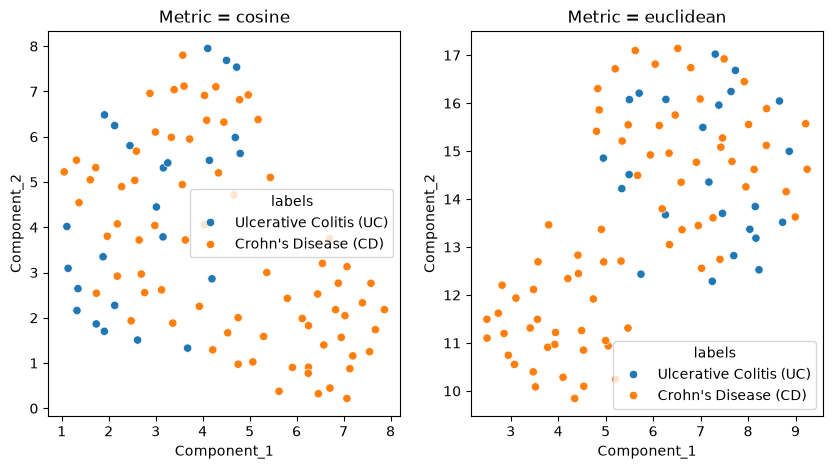

In [22]:
_, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.flatten()
np.random.seed(1022)
for i, metric in enumerate(["cosine", "euclidean"]):
    gene_UMAP = umap.UMAP(min_dist=0.5, n_neighbors=25, metric=metric).fit_transform(gene_data)
    umap_projected = plot_pca(gene_UMAP, labels, ax=ax[i])
    ax[i].set_title("Metric = " + metric)

The default for the UMAP algorithm is to map to a Euclidean space from the specified space. In this case, the difference between the cosine and Euclidean distances is limited. This situation can occur if the vectors are not that different, which is the case for gene expression in this case.           

> **Exercise 2-8:**  Now, answer the following questions in one or a few sentences.
> 1. We have now seen examples of using linear or Euclidean dimensionality reduction and examples non-Euclidean dimensionality reduction. State an example where a linear mapping would not be appropriate.        
> 2. State a few advantages of mapping to a Euclidean space.   

> **Answers:**     
> 1. If we are looking at a documents as embeddings, two documents that are similar in terms of content but have very different lengths would be vectors pointing in similar directions but with different norms. Euclidean distance would see them as more different due to their magnitude difference, but cosine distance would see them as relatively similar.   
> 2. Euclidean distance is easier to explain to a layperson, and similar to visualize without getting into geometry concepts. Also many algorithms work specifically in euclidean space, like k-means which depends on distance from a central point, or standard statistical tests. Mapping data from cosine space into low-dimensional Euclidean space allows the use of those libraries without building special cosine-distance versions.   

###### Copyright 2021, 2022, 2023, 2024, 2025, 2026 Stephen F Elston. All rights reserved.